In [1]:
import pandas as pd

df = pd.read_csv("customer_churn_1000.csv")

df.head()

,customer_id,age,gender,plan,monthly_bill,tenure,support_calls,data_usage,payment_method,churn
0,CUST00001,56,Male,Standard,31.21,61,5,37.03,Bank Transfer,No
1,CUST00002,69,Female,Basic,30.89,59,2,14.18,Bank Transfer,No
2,CUST00003,46,Male,Standard,70.28,22,1,49.28,Mobile Wallet,No
3,CUST00004,32,Female,Standard,52.93,68,5,26.06,Bank Transfer,Yes
4,CUST00005,60,Male,Standard,43.82,4,6,21.46,Bank Transfer,Yes


In [2]:
df.shape

(10020, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     10020 non-null  object 
 1   age             10020 non-null  int64  
 2   gender          10020 non-null  object 
 3   plan            10020 non-null  object 
 4   monthly_bill    9919 non-null   float64
 5   tenure          10020 non-null  int64  
 6   support_calls   10020 non-null  int64  
 7   data_usage      9920 non-null   float64
 8   payment_method  9920 non-null   object 
 9   churn           10020 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 782.9+ KB


In [4]:
df.describe()

,age,monthly_bill,tenure,support_calls,data_usage
count,10020.000000,9919.000000,10020.000000,10020.000000,9920.000000
mean,44.025449,48.062955,35.959082,2.987226,24.063410
std,15.205373,18.679839,20.711439,1.720121,13.836575
min,18.000000,15.000000,1.000000,0.000000,1.000000
25%,31.000000,33.070000,18.000000,2.000000,14.000000
50%,44.000000,45.910000,36.000000,3.000000,21.480000
75%,57.000000,60.060000,54.000000,4.000000,31.330000
max,70.000000,114.620000,72.000000,14.000000,100.000000


In [5]:
# check missing value
df.isnull().sum()

customer_id         0
age                 0
gender              0
plan                0
monthly_bill      101
tenure              0
support_calls       0
data_usage        100
payment_method    100
churn               0
dtype: int64

In [6]:
df.duplicated().sum()

20

In [7]:
df[df.duplicated()]

,customer_id,age,gender,plan,monthly_bill,tenure,support_calls,data_usage,payment_method,churn
10000,CUST06253,52,Female,Basic,45.41,33,0,6.25,Bank Transfer,No
10001,CUST04685,24,Female,Standard,44.99,6,4,16.13,Bank Transfer,No
10002,CUST01732,70,Female,Standard,52.63,34,6,52.70,Card,Yes
10003,CUST04743,43,Female,Basic,33.41,47,0,10.88,Cash,No
10004,CUST04522,43,Female,Standard,52.33,26,2,9.20,Bank Transfer,No
10005,CUST06341,21,Female,Basic,37.03,12,4,24.15,Cash,No
10006,CUST00577,54,Male,Premium,85.29,42,2,20.75,Mobile Wallet,No
10007,CUST05203,39,Male,Standard,50.46,42,6,16.29,Cash,No
10008,CUST06364,59,Female,Basic,27.66,52,2,5.17,Cash,No
10009,CUST00440,62,Male,Basic,44.68,58,2,36.23,Mobile Wallet,No


In [8]:
df["churn"].value_counts()

churn
No     8395
Yes    1625
Name: count, dtype: int64

In [9]:
df["age"].value_counts()

age
43    225
66    216
62    216
40    212
34    210
64    209
52    208
45    205
38    204
30    200
35    200
49    200
46    199
42    197
19    196
29    195
21    195
39    195
68    193
56    193
59    192
54    192
32    191
57    191
37    190
41    189
51    189
25    188
61    188
20    188
22    188
33    187
23    186
53    186
70    184
55    183
36    183
47    183
28    182
50    182
69    178
26    177
18    176
31    175
27    175
65    175
58    174
67    174
63    169
24    162
60    162
44    159
48    154
Name: count, dtype: int64

In [10]:
df["gender"].value_counts()

gender
Female    5033
Male      4987
Name: count, dtype: int64

In [11]:
df["churn"].value_counts(normalize=True) * 100

churn
No     83.782435
Yes    16.217565
Name: proportion, dtype: float64

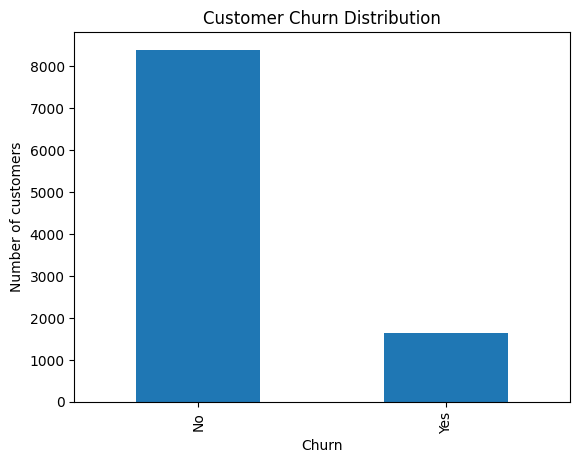

In [12]:
import matplotlib.pyplot as plt

df["churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
plt.show()

In [13]:
# Do customer who churn have higher monthly bills?
df.groupby("churn")["monthly_bill"].mean()

churn
No     46.399402
Yes    56.648335
Name: monthly_bill, dtype: float64

In [14]:
# now on support call
df.groupby("churn")["support_calls"].mean()

churn
No     2.897677
Yes    3.449846
Name: support_calls, dtype: float64

In [15]:
df.groupby("churn")["tenure"].mean()

churn
No     37.978797
Yes    25.524923
Name: tenure, dtype: float64

In [16]:
# into categorical analysis
pd.crosstab(
    df["plan"],
    df["churn"],
    normalize="index"
) * 100

churn,No,Yes
plan,,
Basic,89.255499,10.744501
Premium,70.833333,29.166667
Standard,85.207497,14.792503


In [17]:
pd.crosstab(
    df["payment_method"],
    df["churn"],
    normalize = "index"
) * 100

churn,No,Yes
payment_method,,
Bank Transfer,83.601934,16.398066
Card,84.003548,15.996452
Cash,82.099596,17.900404
Mobile Wallet,84.552529,15.447471


In [18]:
pd.crosstab(
    df["gender"],
    df["churn"],
    normalize = "index"
) * 100

churn,No,Yes
gender,,
Female,83.608186,16.391814
Male,83.958292,16.041708


In [19]:
print("=== Churn ===")
print(df["churn"].value_counts(normalize=True) * 100)

print("\n=== Support Calls ===")
print(df.groupby("churn")["support_calls"].mean())

print("\n=== Plan ===")
print(
    pd.crosstab(
        df["plan"],
        df["churn"],
        normalize="index"
    ) * 100
)

print("\n=== Payment Method ===")
print(
    pd.crosstab(
        df["payment_method"],
        df["churn"],
        normalize="index"
    ) * 100
)

print("\n=== Gender ===")
print(
    pd.crosstab(
        df["gender"],
        df["churn"],
        normalize="index"
    ) * 100
)

=== Churn ===
churn
No     83.782435
Yes    16.217565
Name: proportion, dtype: float64

=== Support Calls ===
churn
No     2.897677
Yes    3.449846
Name: support_calls, dtype: float64

=== Plan ===
churn            No        Yes
plan                          
Basic     89.255499  10.744501
Premium   70.833333  29.166667
Standard  85.207497  14.792503

=== Payment Method ===
churn                  No        Yes
payment_method                      
Bank Transfer   83.601934  16.398066
Card            84.003548  15.996452
Cash            82.099596  17.900404
Mobile Wallet   84.552529  15.447471

=== Gender ===
churn          No        Yes
gender                      
Female  83.608186  16.391814
Male    83.958292  16.041708


In [20]:
df.groupby("churn")["monthly_bill"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
churn,,,,
No,46.399402,44.270,15.0,114.62
Yes,56.648335,55.405,15.0,113.02


In [21]:
df.groupby("churn")["tenure"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
churn,,,,
No,37.978797,39.0,1,72
Yes,25.524923,22.0,1,72


In [22]:
df.groupby("churn")["data_usage"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
churn,,,,
No,24.217162,21.705,1.0,100.0
Yes,23.270999,20.385,1.0,100.0


In [23]:
df.groupby("churn")["age"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
churn,,,,
No,43.916379,44.0,18,70
Yes,44.588923,45.0,18,70


In [24]:
# Correlation Analysis
numeric_cols = [
    "age",
    "monthly_bill",
    "tenure",
    "support_calls",
    "data_usage"
]

corr = df[numeric_cols].corr()
print(corr)

                    age  monthly_bill    tenure  support_calls  data_usage
age            1.000000      0.008766  0.002987      -0.010356    0.003377
monthly_bill   0.008766      1.000000 -0.008704      -0.010606   -0.019565
tenure         0.002987     -0.008704  1.000000       0.010242   -0.007564
support_calls -0.010356     -0.010606  0.010242       1.000000    0.000506
data_usage     0.003377     -0.019565 -0.007564       0.000506    1.000000


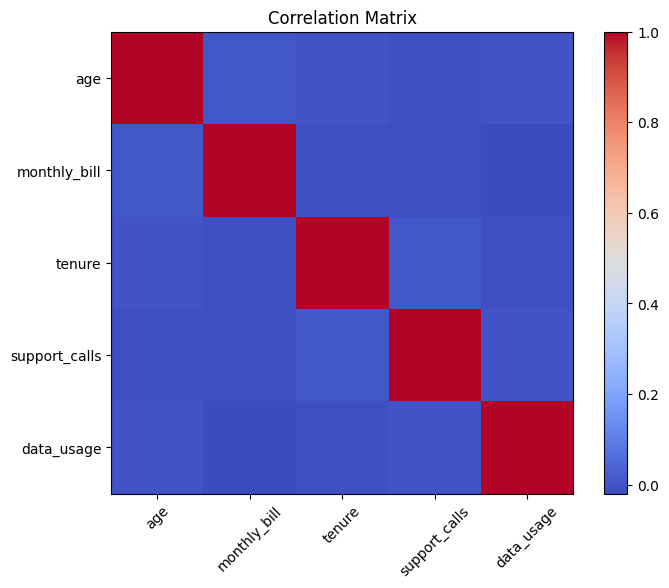

In [25]:
# Visulalize correlation, create heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation= 45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()



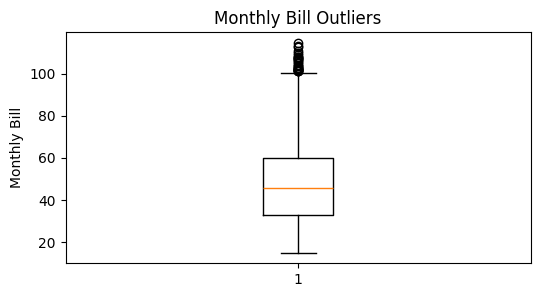

In [26]:
# FInd the outliers of monthly_bill
plt.figure(figsize=(6, 3))

plt.boxplot(
    df["monthly_bill"].dropna()
)

plt.title("Monthly Bill Outliers")
plt.ylabel("Monthly Bill")
plt.show()

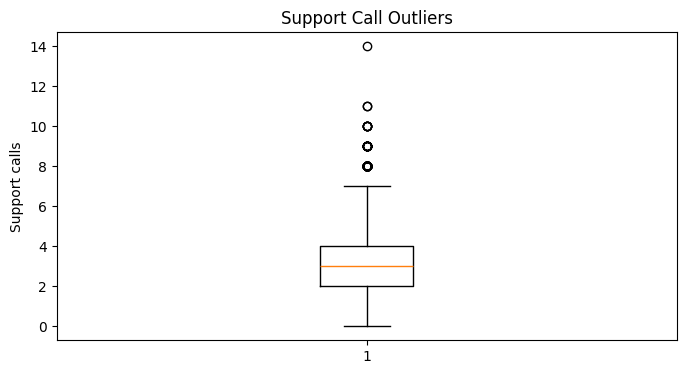

In [27]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df["support_calls"]
)

plt.title("Support Call Outliers")
plt.ylabel("Support calls")
plt.show()

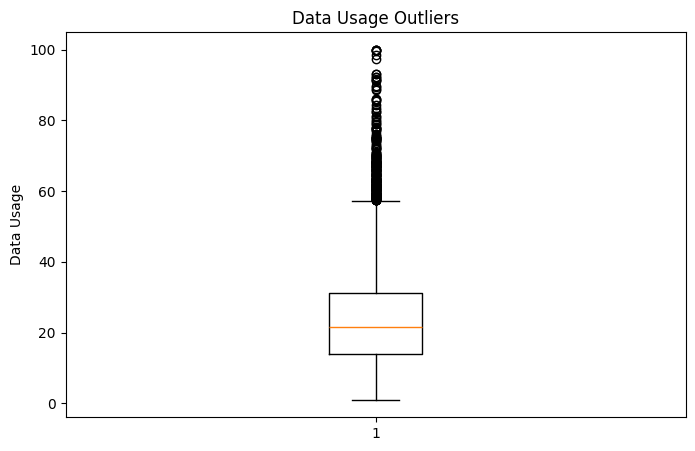

In [28]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df["data_usage"].dropna()
)

plt.title("Data Usage Outliers")
plt.ylabel("Data Usage")

plt.show()


churn              No        Yes
bill_group                      
0-30        90.984975   9.015025
31-50       87.774137  12.225863
51-70       81.164762  18.835238
71-100      69.192635  30.807365
100+        43.333333  56.666667


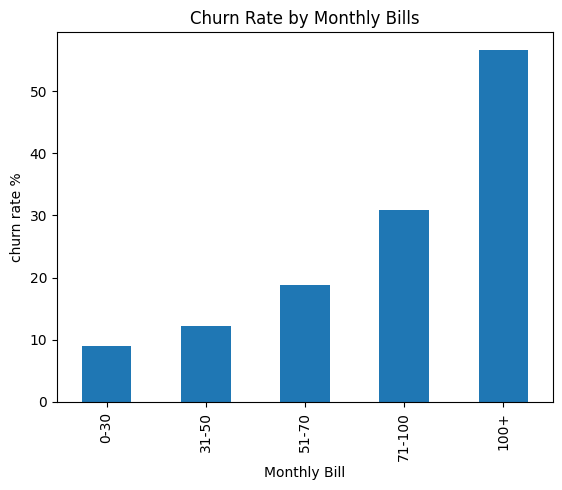

In [32]:
# Looking monthly bill and churn together
# create bill groups

df["bill_group"] = pd.cut(
    df["monthly_bill"],
    bins=[0, 30, 50, 70, 100, 150],
    labels = [
        "0-30",
        "31-50",
        "51-70",
        "71-100",
        "100+"
    ]
)

bill_churn = pd.crosstab(
    df["bill_group"],
    df["churn"],
    normalize="index"
) * 100

print(bill_churn)

bill_churn["Yes"].plot(kind="bar")

plt.title("Churn Rate by Monthly Bills")
plt.xlabel("Monthly Bill")
plt.ylabel("churn rate %")
plt.show()

In [33]:
# Support Call and Churn
support_churn = pd.crosstab(
    df["support_calls"],
    df["churn"],
    normalize="index"
) * 100

print(support_churn)

churn                  No         Yes
support_calls                        
0               91.217565    8.782435
1               88.881447   11.118553
2               85.441633   14.558367
3               84.185022   15.814978
4               82.115722   17.884278
5               79.896373   20.103627
6               73.170732   26.829268
7               72.398190   27.601810
8               69.767442   30.232558
9               57.894737   42.105263
10             100.000000    0.000000
11             100.000000    0.000000
14               0.000000  100.000000


In [35]:
df.groupby("plan")["support_calls"].mean()

plan
Basic       2.994924
Premium     2.978414
Standard    2.985051
Name: support_calls, dtype: float64

In [36]:
df.groupby(["plan", "churn"])["support_calls"].mean()

plan      churn
Basic     No       2.940916
          Yes      3.443570
Premium   No       2.835578
          Yes      3.325301
Standard  No       2.884787
          Yes      3.562594
Name: support_calls, dtype: float64

In [37]:
# Create high risk customer profile
high_risk = df[
    (df["support_calls"] >= 6) &
    (df["tenure"] <= 12) &
    (df["monthly_bill"] >= 50)
]

print(high_risk.head())
print(high_risk.shape)

    customer_id  age  gender      plan  monthly_bill  tenure  support_calls  \
137   CUST00138   61    Male  Standard         63.93       5              6   
152   CUST00153   56    Male  Standard         52.58       8              7   
302   CUST00303   65  Female   Premium         77.64       8              8   
550   CUST00551   69  Female  Standard         61.77       3              6   
596   CUST00597   43    Male  Standard         54.50      10              6   

     data_usage payment_method churn bill_group  
137       65.88           Card   Yes      51-70  
152       20.65  Mobile Wallet   Yes      51-70  
302       24.73  Bank Transfer    No     71-100  
550       33.69           Cash   Yes      51-70  
596       30.35  Mobile Wallet    No      51-70  
(59, 11)


In [38]:
high_risk["churn"].value_counts(normalize=True) * 100

churn
Yes    54.237288
No     45.762712
Name: proportion, dtype: float64

In [39]:
# find the top churn segment
segment = df.groupby(
    ["plan", "payment_method"]
)["churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).reset_index()

segment.columns = [
    "plan",
    "payment_method",
    "churn_rate"
]

segment = segment.sort_values(
    "churn_rate",
    ascending=False
)

print(segment)

        plan payment_method  churn_rate
6    Premium           Cash   31.972789
4    Premium  Bank Transfer   30.184805
7    Premium  Mobile Wallet   28.927203
5    Premium           Card   27.678571
10  Standard           Cash   17.474302
8   Standard  Bank Transfer   14.851485
9   Standard           Card   14.775726
11  Standard  Mobile Wallet   13.120567
1      Basic           Card   10.971524
0      Basic  Bank Transfer   10.746606
3      Basic  Mobile Wallet   10.652174
2      Basic           Cash   10.371820
